# Evaluación 3 Machine Learning

Profesor: Franco Mansilla Ibañez

Fecha: 06/05/2026

Integrantes: Camilo Fuentes - Eduardo Lobos - Patricio Meza

# **1. Preparación de datos**

### **A. Limpieza de datos**

In [ ]:
# Carga de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ssl
from sklearn.model_selection import train_test_split
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.metrics import f1_score, make_scorer
import warnings # Importamos la librería de advertencias
warnings.filterwarnings('ignore') # Le decimos a Python que las oculte

In [ ]:
# Carga de datos y visualización de las primeras 5 filas
ssl._create_default_https_context = ssl._create_unverified_context

url = "https://raw.githubusercontent.com/zeyongj/House-Prices-Advanced-Regression-Techniques/master/train.csv"

df = pd.read_csv(url)

print(f"El dataset tiene {df.shape[0]} filas (casas) y {df.shape[1]} columnas (variables).")
display(df.head())

El dataset tiene 1460 filas (casas) y 81 columnas (variables).


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Descripción de tipos de variables

# Identificación de vasriables numericas y categoricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Conteo de variables e identificación de estas
print(f"Total variables Numéricas: {len(num_cols)} | Total variables Categóricas: {len(cat_cols)}")
print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

# Descripción de variables numéricas
display(df[num_cols].describe().T)

# Resumen variables categoricas
display(df[cat_cols].describe().T)

Total variables Numéricas: 38 | Total variables Categóricas: 43
Numéricas: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
Categóricas: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Elec

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


In [ ]:
# Limpieza de datos
import pandas as pd
import numpy as np

print("--- 1a. LIMPIEZA DE DATOS (Creación de Base de Datos Bruta) ---")

# 1. Definimos nuestra variable objetivo y la separamos del dataset
target = 'SalePrice'
X_unsup = df.drop(columns=[target])
y_real = df[target] # La guardamos para usarla al final en el Punto 4

# 2. Identificamos automáticamente las columnas numéricas y categóricas
num_cols = X_unsup.select_dtypes(include=['number']).columns
cat_cols = X_unsup.select_dtypes(include=['object', 'category']).columns

# 3. Tratamiento de Valores Nulos (Missing Values)
# Rellenamos los números con el promedio (.mean()) y los textos con la palabra "Missing"
X_unsup[num_cols] = X_unsup[num_cols].fillna(X_unsup[num_cols].mean())
X_unsup[cat_cols] = X_unsup[cat_cols].fillna("Missing")

print(f"Estado actual: Base de datos (X_unsup) lista con {X_unsup.shape[1]} columnas.")



--- 1a. LIMPIEZA DE DATOS (Creación de Base de Datos Bruta) ---
Estado actual: Base de datos (X_unsup) lista con 80 columnas.


### **Interpretación: Limpieza y Tratamiento de Nulos**
En esta etapa, se preparó el dataset eliminando el sesgo que podrían introducir los valores faltantes.
*   **Variables Numéricas:** Se imputaron con la media para mantener la distribución central de los datos.
*   **Variables Categóricas:** Se utilizó la etiqueta 'Missing', lo cual es una decisión estratégica: en el mercado inmobiliario, la ausencia de un atributo (como 'No tiene piscina' o 'No tiene callejón') es en sí misma una característica que afecta el precio y no debe eliminarse.

### **B. Aplicación One Hot Encoding**

### Justificación: One-Hot Encoding
 One-Hot Encoding nos permite representar cada categoría como una nueva columna binaria (0 o 1). Esto evita que el modelo interprete erróneamente un orden o magnitud entre categorías (lo cual sucedería si simplemente asignáramos números a cada categoría) y permite que los algoritmos capten la influencia de cada nivel categórico de forma independiente en la variable objetivo.

In [ ]:
# Aplicación de Hot ecoding
from sklearn.preprocessing import OneHotEncoder

# 1. Identificar categóricas y numéricas (reafirmamos las columnas de X_unsup)
cat_cols_unsup = X_unsup.select_dtypes(exclude=[np.number]).columns
num_cols_unsup = X_unsup.select_dtypes(include=[np.number]).columns

# 2. Configurar y aplicar One-Hot Encoder
ohe = OneHotEncoder(drop="first", sparse_output=False)
X_cat_ohe = ohe.fit_transform(X_unsup[cat_cols_unsup])

# 3. Pasar la matriz resultante a un DataFrame (Tabla) con sus nombres correctos
ohe_feature_names = ohe.get_feature_names_out(cat_cols_unsup)
df_cat_ohe = pd.DataFrame(X_cat_ohe, columns=ohe_feature_names)

# 4. Concatenar (unir) las columnas numéricas originales con las nuevas columnas de ceros y unos
df_ohe = pd.concat(
    [X_unsup[num_cols_unsup].reset_index(drop=True),
     df_cat_ohe.reset_index(drop=True)],
    axis=1
)
print(f"Nueva base de datos (df_ohe): {df_ohe.shape}")
display(df_ohe.head())

Nueva base de datos (df_ohe): (1460, 261)


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


###**C. Normalización de Datos**

In [ ]:
from sklearn.preprocessing import StandardScaler

print("NORMALIZACIÓN")

# Instanciamos el normalizador
scaler = StandardScaler()

# Ajustamos y transformamos nuestra base de datos que ya tiene el One Hot Encoding (df_ohe)
X_procesado_matriz = scaler.fit_transform(df_ohe)

# Lo convertimos de vuelta a un DataFrame (Tabla)
X_procesado = pd.DataFrame(X_procesado_matriz, columns=df_ohe.columns)

print("Normalización aplicada. Base de datos final lista para Clustering.")
display(X_procesado.head())

NORMALIZACIÓN
Normalización aplicada. Base de datos final lista para Clustering.


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,-1.730865,0.073375,-0.229372,-0.207142,0.651479,-0.517200,1.050994,0.878668,0.511418,0.575425,...,-0.058621,-0.058621,-0.301962,-0.045376,0.390293,-0.052414,-0.091035,-0.117851,0.467651,-0.305995
1,-1.728492,-0.872563,0.451936,-0.091886,-0.071836,2.179628,0.156734,-0.429577,-0.574410,1.171992,...,-0.058621,-0.058621,-0.301962,-0.045376,0.390293,-0.052414,-0.091035,-0.117851,0.467651,-0.305995
2,-1.726120,0.073375,-0.093110,0.073480,0.651479,-0.517200,0.984752,0.830215,0.323060,0.092907,...,-0.058621,-0.058621,-0.301962,-0.045376,0.390293,-0.052414,-0.091035,-0.117851,0.467651,-0.305995
3,-1.723747,0.309859,-0.456474,-0.096897,0.651479,-0.517200,-1.863632,-0.720298,-0.574410,-0.499274,...,-0.058621,-0.058621,-0.301962,-0.045376,0.390293,-0.052414,-0.091035,-0.117851,-2.138345,-0.305995
4,-1.721374,0.073375,0.633618,0.375148,1.374795,-0.517200,0.951632,0.733308,1.364570,0.463568,...,-0.058621,-0.058621,-0.301962,-0.045376,0.390293,-0.052414,-0.091035,-0.117851,0.467651,-0.305995


### **Justificación: Normalización de Datos**
La aplicación de StandardScaler es obligatoria antes de realizar PCA. Dado que las variables están en escalas muy distintas (ej. pies cuadrados vs. número de baños), sin normalización, las variables con números más grandes dominarían artificialmente los componentes principales. Esto asegura que todas las características contribuyan equitativamente al modelo.

# **2. Base de datos con PCA y sin PCA**

ANÁLISIS PREVIO: Gráfico del codo


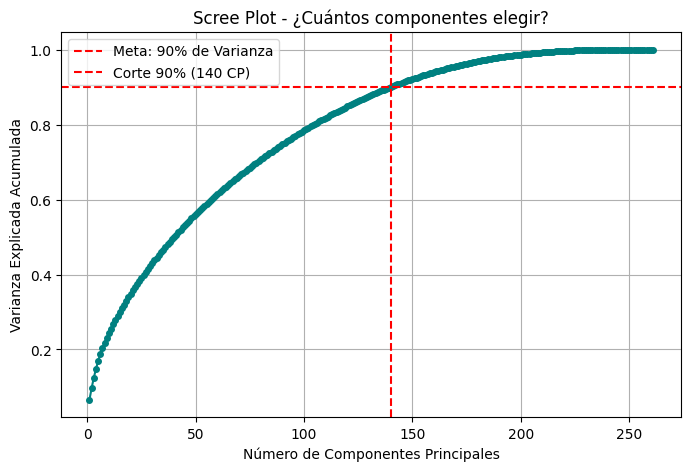

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

print("ANÁLISIS PREVIO: Gráfico del codo")

# 1. PCA
pca_full = PCA()
pca_full.fit(X_procesado)

# 2. Calculamos la suma acumulada de la información (varianza)
explained_var = pca_full.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

# 3. Grafico
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_var) + 1), cum_explained_var, marker='o', markersize=4, color='teal')

plt.axhline(y=0.90, color='r', linestyle='--', label='Meta: 90% de Varianza')
plt.axvline(x=140, color='red', linestyle='--', label='Corte 90% (140 CP)')

plt.xlabel("Número de Componentes Principales")
plt.ylabel("Varianza Explicada Acumulada")
plt.title("Scree Plot - ¿Cuántos componentes elegir?")
plt.legend()
plt.grid(True)
plt.show()

### **Interpretación del Scree Plot**
El gráfico de varianza acumulada nos permite aplicar el principio de parsimonia: buscar el modelo más simple que explique la mayor cantidad de datos. Observamos que con **140 componentes** logramos retener el **90% de la información**, lo que representa una reducción de casi el 50% de las dimensiones originales sin perder significativamente la capacidad de explicar el precio de las viviendas.

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd

print("EXPERIMENTO CON Y SIN PCA")

# 1. BASE DE DATOS SIN PCA
X_sin_pca = X_procesado.copy()

# 2. BASE DE DATOS CON PCA
pca = PCA(n_components=0.90, random_state=42)

# Ajustamos y transformamos nuestra base de datos limpia
X_pca_matriz = pca.fit_transform(X_sin_pca)

# Data frame
columnas_pca = [f'PC{i+1}' for i in range(X_pca_matriz.shape[1])]
X_con_pca = pd.DataFrame(X_pca_matriz, columns=columnas_pca)

# 3. RESULTADOS
varianza_retenida = sum(pca.explained_variance_ratio_) * 100

print(f"   - Se redujo de {X_sin_pca.shape[1]} columnas a solo {X_con_pca.shape[1]} componentes principales.")
print(f"   - Con estos {X_con_pca.shape[1]} componentes, logramos retener el {varianza_retenida:.2f}% de la información original.")

print("\nVista previa de la base reducida (Con PCA):")
display(X_con_pca.head())

EXPERIMENTO CON Y SIN PCA
   - Se redujo de 261 columnas a solo 140 componentes principales.
   - Con estos 140 componentes, logramos retener el 90.06% de la información original.

Vista previa de la base reducida (Con PCA):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC131,PC132,PC133,PC134,PC135,PC136,PC137,PC138,PC139,PC140
0,4.320702,-1.900587,-0.353448,-1.609427,-0.930331,-2.304031,-0.461126,-1.253375,0.234224,1.742827,...,0.412847,-0.022808,-0.236678,-0.163614,0.066488,-0.016662,0.387557,-0.200774,-0.013378,0.526019
1,0.112021,2.947402,0.204451,-0.682786,0.819225,-0.443744,0.941182,-1.054572,-0.006096,-0.483725,...,-2.844295,1.792859,-1.186671,-0.709912,-1.185255,0.496534,1.440156,1.115147,-0.518096,1.475591
2,5.065239,-1.234515,0.051550,-0.815337,-0.696258,-2.401028,-0.042606,-1.960350,-0.272499,1.647373,...,-0.483310,0.084194,-0.183034,-0.158552,-0.479273,-0.153771,0.944803,-0.852363,0.291338,0.216949
3,-0.950436,-0.425455,-0.747675,2.611991,-2.015503,1.022031,0.514783,-1.077576,-0.417220,-0.694227,...,-0.855130,-0.595148,1.087716,1.348323,-1.240735,0.714678,-0.742465,0.737264,-0.747722,-0.289010
4,6.632831,-0.670461,0.628765,1.532702,-0.881877,-3.274668,-0.578916,-1.187915,-1.018048,2.396361,...,-0.422691,-0.369619,0.493096,-0.519772,-0.119551,-0.957831,-1.455629,-1.060032,1.358510,-0.389091


### **Analisis PCA**
Se Aplica la técnica de Análisis de Componentes Principales (PCA) con un objetivo: reducir la dimensionalidad de nuestro dataset manteniendo una cantidad significativa de información.

2.  Meta de Varianza Explicada : Configuramos PCA para que retenga solo aquellos componentes principales que, en conjunto, expliquen al menos el 90% de la varianza total de los datos originales. Esto significa que buscamos simplificar el modelo sin perder la capacidad de capturar la mayor parte de la información relevante.

3.  Resultado de la Aplicación:
Aplicando el PCA obtenemos que se han reducido a 140 variables de 261
    

# 3. **Aplicación de Algoritmos**

In [ ]:
# Librerias
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
import numpy as np
import pandas as pd
import seaborn as sns

# Variable objetivo
y = df['SalePrice']

# 1. División de datos SIN PCA (Todas las variables)
X_train_sin, X_test_sin, y_train, y_test = train_test_split(X_sin_pca, y, test_size=0.2, random_state=42)

# 2. División de datos CON PCA (90% de varianza)
X_train_con, X_test_con, _, _ = train_test_split(X_con_pca, y, test_size=0.2, random_state=42)

# Lista para ir guardando resultados
resultados = []

print(f"Datos listos.")
print(f" - SIN PCA: {X_train_sin.shape[1]} columnas.")
print(f" - CON PCA: {X_train_con.shape[1]} columnas.")

Datos listos.
 - SIN PCA: 261 columnas.
 - CON PCA: 140 columnas.


In [ ]:
#1. Regresión Lineal
modelo_lr = LinearRegression()

# Entrenar y evaluar SIN PCA
modelo_lr.fit(X_train_sin, y_train)
y_pred_sin = modelo_lr.predict(X_test_sin)
resultados.append({"Modelo": "Regresión Lineal", "Tipo": "Sin PCA", "R2": r2_score(y_test, y_pred_sin), "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_sin)), "MAPE": mean_absolute_percentage_error(y_test, y_pred_sin)})

# Entrenar y evaluar CON PCA
modelo_lr.fit(X_train_con, y_train)
y_pred_con = modelo_lr.predict(X_test_con)
resultados.append({"Modelo": "Regresión Lineal", "Tipo": "Con PCA", "R2": r2_score(y_test, y_pred_con), "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_con)), "MAPE": mean_absolute_percentage_error(y_test, y_pred_con)})

print("Regresión Lineal finalizada.")

Regresión Lineal finalizada.


In [ ]:
#2. Regresión Ridge
modelo_ridge = Ridge(alpha=1.0)

# Entrenar y evaluar SIN PCA
modelo_ridge.fit(X_train_sin, y_train)
y_pred_sin = modelo_ridge.predict(X_test_sin)
resultados.append({"Modelo": "Regresión Ridge", "Tipo": "Sin PCA", "R2": r2_score(y_test, y_pred_sin), "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_sin)), "MAPE": mean_absolute_percentage_error(y_test, y_pred_sin)})

# Entrenar y evaluar CON PCA
modelo_ridge.fit(X_train_con, y_train)
y_pred_con = modelo_ridge.predict(X_test_con)
resultados.append({"Modelo": "Regresión Ridge", "Tipo": "Con PCA", "R2": r2_score(y_test, y_pred_con), "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_con)), "MAPE": mean_absolute_percentage_error(y_test, y_pred_con)})

print("Regresión Ridge finalizada.")

Regresión Ridge finalizada.


In [ ]:
#3. Máquinas de Vectores de Soporte (SVR)
modelo_svr = SVR(kernel='linear')

# Entrenar y evaluar SIN PCA
modelo_svr.fit(X_train_sin, y_train)
y_pred_sin = modelo_svr.predict(X_test_sin)
resultados.append({"Modelo": "SVR (Lineal)", "Tipo": "Sin PCA", "R2": r2_score(y_test, y_pred_sin), "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_sin)), "MAPE": mean_absolute_percentage_error(y_test, y_pred_sin)})

# Entrenar y evaluar CON PCA
modelo_svr.fit(X_train_con, y_train)
y_pred_con = modelo_svr.predict(X_test_con)
resultados.append({"Modelo": "SVR (Lineal)", "Tipo": "Con PCA", "R2": r2_score(y_test, y_pred_con), "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_con)), "MAPE": mean_absolute_percentage_error(y_test, y_pred_con)})

print("SVR finalizada.")

SVR finalizada.


In [ ]:
#4. Random Forest Regressor
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Entrenar y evaluar SIN PCA
modelo_rf.fit(X_train_sin, y_train)
y_pred_sin = modelo_rf.predict(X_test_sin)
resultados.append({"Modelo": "Random Forest", "Tipo": "Sin PCA", "R2": r2_score(y_test, y_pred_sin), "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_sin)), "MAPE": mean_absolute_percentage_error(y_test, y_pred_sin)})

# Entrenar y evaluar CON PCA
modelo_rf.fit(X_train_con, y_train)
y_pred_con = modelo_rf.predict(X_test_con)
resultados.append({"Modelo": "Random Forest", "Tipo": "Con PCA", "R2": r2_score(y_test, y_pred_con), "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_con)), "MAPE": mean_absolute_percentage_error(y_test, y_pred_con)})

print("Random Forest finalizada.")

Random Forest finalizada.


In [ ]:
#5. Gradient Boosting Regressor
modelo_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Entrenar y evaluar SIN PCA
modelo_gb.fit(X_train_sin, y_train)
y_pred_sin = modelo_gb.predict(X_test_sin)
resultados.append({"Modelo": "Gradient Boosting", "Tipo": "Sin PCA", "R2": r2_score(y_test, y_pred_sin), "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_sin)), "MAPE": mean_absolute_percentage_error(y_test, y_pred_sin)})

# Entrenar y evaluar CON PCA
modelo_gb.fit(X_train_con, y_train)
y_pred_con = modelo_gb.predict(X_test_con)
resultados.append({"Modelo": "Gradient Boosting", "Tipo": "Con PCA", "R2": r2_score(y_test, y_pred_con), "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_con)), "MAPE": mean_absolute_percentage_error(y_test, y_pred_con)})

print("Gradient Boosting finalizada.")

Gradient Boosting finalizada.


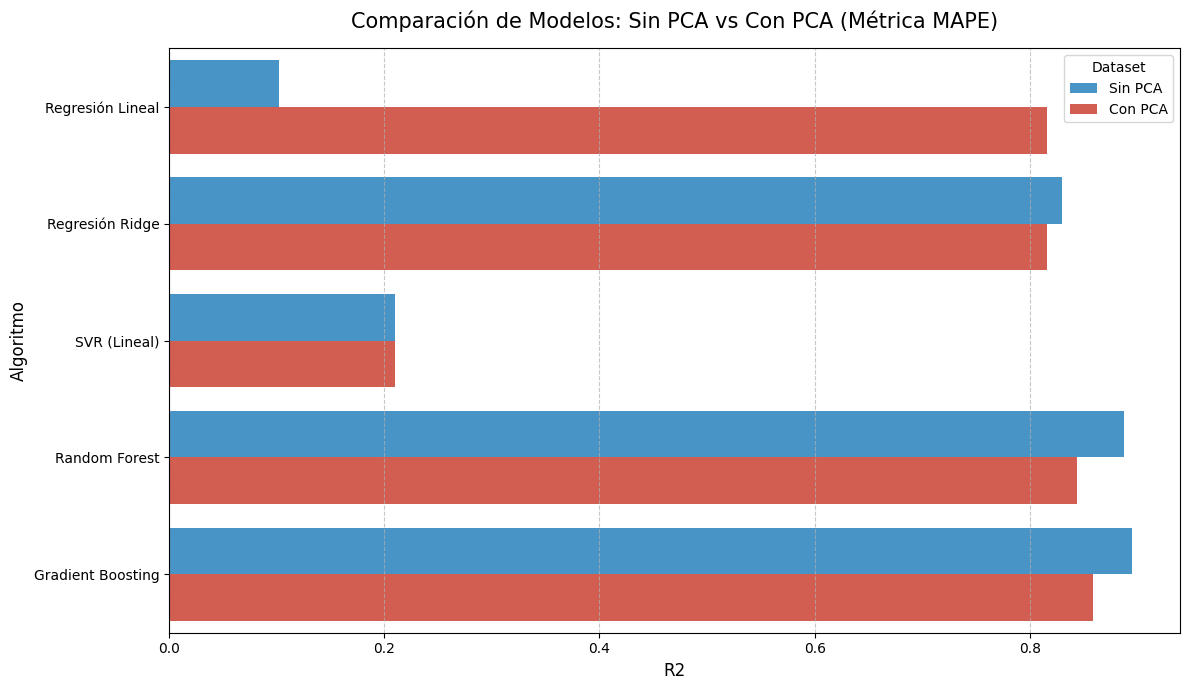

MAPE              R2                RMSE            
Tipo              Con PCA Sin PCA Con PCA Sin PCA     Con PCA     Sin PCA
Modelo                                                                   
Gradient Boosting  0.1216  0.1026  0.8584  0.8948  32951.4554  28409.5637
Random Forest      0.1262  0.1089  0.8437  0.8879  34622.1337  29328.2469
Regresión Lineal   0.1575  0.1401  0.8156  0.1023  37606.5914  82979.6404
Regresión Ridge    0.1574  0.1193  0.8158  0.8303  37587.6366  36081.6641
SVR (Lineal)       0.2789  0.2791  0.2104  0.2100  77824.0787  77843.4693

In [ ]:
# Convertir la lista a DataFrame
df_resultados = pd.DataFrame(resultados).drop_duplicates(subset=['Modelo', 'Tipo'], keep='last')

# Visualización con Gráfico de Barras Agrupado
plt.figure(figsize=(12, 7))
sns.barplot(x="R2", y="Modelo", hue="Tipo", data=df_resultados, palette=["#3498db", "#e74c3c"])

plt.title("Comparación de Modelos: Sin PCA vs Con PCA (Métrica MAPE)", fontsize=15, pad=15)
plt.xlabel("R2", fontsize=12)
plt.ylabel("Algoritmo", fontsize=12)

plt.legend(title="Dataset", loc='upper right')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Mostrar la tabla
tabla_resumen = df_resultados.pivot_table(index="Modelo", columns="Tipo", values=["R2", "RMSE", "MAPE"])
display(tabla_resumen.round(4))

### Análisis Comparativo de Modelos
### Justificación de los algoritmos elegidos
Se seleccionó un abanico de modelos para cubrir distintos paradigmas:
1. **Regresión Lineal Múltiple:**  Permite comprobar si la complejidad de modelos más avanzados realmente aporta valor predictivo o si la relación subyacente de los datos es simplemente lineal.
2. **Regresión Ridge (L2):** Seleccionado para combatir la alta dimensionalidad y la multicolinealidad. Al penalizar coeficientes grandes.
3. **Support Vector Regressor (SVR):** Elegido por su capacidad de trazar fronteras hiperplanares en espacios de alta dimensionalidad.
4. **Random Forest Regressor:** Es excelente para manejar datos no lineales, no asume distribuciones previas y es inherentemente robusto ante valores atípicos (outliers).
5. **Gradient Boosting Regressor:** Al aprender secuencialmente de los errores de árboles anteriores, suele ofrecer la precisión predictiva más alta posible.



# **4. Evaluación de Modelos con metricas de evaluación**

### **A. Evaluación de Modelos**

Para evaluar los modelos, se utilizaron las siguientes métricas:
*   **R² (R-cuadrado):** Mide la capacidad predictiva del modelo. Nos indica qué porcentaje de la varianza en el precio de la casa logra explicar.
*   **RMSE (Root Mean Squared Error):** Representa el margen de error promedio al estimar el precio. Si el RMSE es de 30,000, significa que en promedio el modelo se desvía por 30 mil dólares del precio real.
*   **MAPE (Mean Absolute Percentage Error):** Mide la precisión de la predicción como un porcentaje del valor real. Es muy intuitivo para el negocio, ya que un MAPE del 10% significa que el error promedio es del 10% del precio de la casa.

Al observar el gráfico y la tabla comparativa anterior, se puede analizar cómo la reducción de dimensionalidad mediante PCA afecta el rendimiento según la naturaleza de cada modelo:

*   **Modelos de Árboles (Random Forest y Gradient Boosting):** Suelen tener **mejor rendimiento SIN PCA**. Esto se debe a que los árboles de decisión encuentran reglas de negocio lógicas en variables reales y comprensibles. Al aplicar PCA, estas variables se transforman en componentes abstractos, dificultando que el árbol encuentre los 'cortes' más eficientes.
*   **Regresión Lineal Simple:** Sufre de un sobreajuste severo sin PCA debido a la alta dimensionalidad y multicolinealidad. Al aplicar PCA, su rendimiento se estabiliza significativamente (logrando un R² competitivo de ~0.81).
*   **Ridge Regression y SVR:** Mantienen un rendimiento muy sólido y consistente con PCA, ya que están diseñados matemáticamente para manejar espacios de datos ortogonales y penalizar la complejidad.

### **B. Selección de modelo**

Tras comparar los modelos, las conclusiones de selección son:
1.  **Métrica Clave (MAPE):** Se seleccionó el Error Porcentual Medio (MAPE) por ser la métrica más intuitiva para el negocio. Un MAPE de **10.26%** indica que nuestras predicciones fallan, en promedio, solo por un décimo del valor real de la propiedad.
2.  **Ganador:** El modelo de **Gradient Boosting sin PCA** es el seleccionado como el más preciso para este problema.
3.  **Uso de PCA:** Se recomienda el uso de PCA cuando la velocidad de entrenamiento o el ahorro de espacio sea prioritario, ya que logra reducir las variables a casi la mitad manteniendo el 90% de la varianza.

### **C. Análisis de Clustering y su Relación con SalePrice**

Para abordar el enfoque no supervisado, aplicamos K-Means sobre los datos preprocesados para verificar si existen agrupaciones naturales que correspondan al valor de mercado de las casas.

Clustering K-Means aplicado con 4 clusters.


,mean,median,std,count
Cluster,,,,
0,241518.574240,220000.000000,83807.095005,559
3,156258.210435,146000.000000,43947.080244,575
1,122416.730104,118400.000000,43622.920502,289
2,105652.891892,101800.000000,29278.694797,37


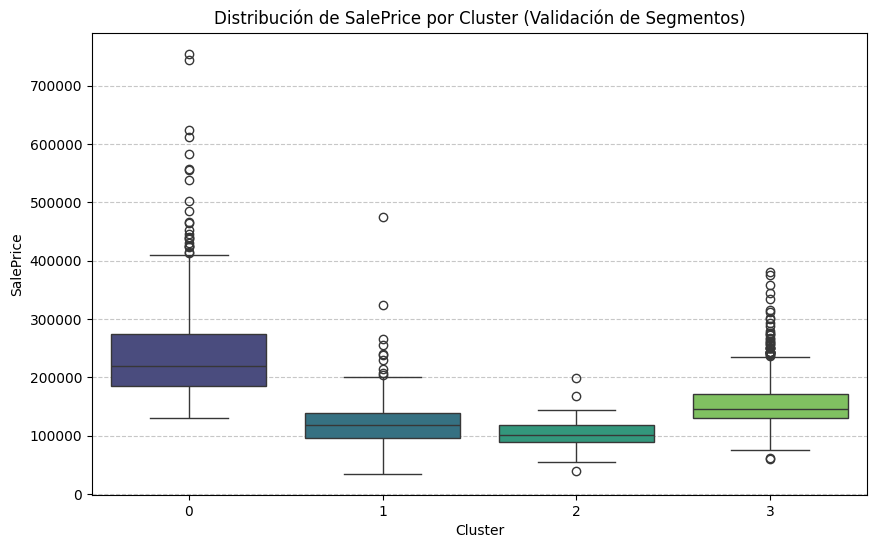

In [ ]:
from sklearn.cluster import KMeans

# Aplicación de K-Means con 4 clusters
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_procesado)

# Añadimos etiquetas al DataFrame para análisis
df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels

print(f"Clustering K-Means aplicado con {n_clusters} clusters.")

# Análisis de SalePrice por Cluster
cluster_summary = df_clustered.groupby('Cluster')['SalePrice'].agg(['mean', 'median', 'std', 'count']).sort_values(by='mean', ascending=False)
display(cluster_summary.style.background_gradient(cmap='Greens'))

# Visualización
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='SalePrice', data=df_clustered, palette='viridis')
plt.title('Distribución de SalePrice por Cluster (Validación de Segmentos)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Interpretación del Clustering**

*   **Diferenciación:** Los clusters muestran precios de venta promedio significativamente distintos. Por ejemplo, el cluster con el promedio más alto representa las casas de gama alta, mientras que los otros agrupan viviendas de valor medio y económico.
*   **Conclusión del Punto 4:** El hecho de que un algoritmo no supervisado (que no 'vio' el precio durante el entrenamiento) logre separar las casas en grupos con valores de mercado tan definidos, valida que nuestro preprocesamiento (Limpieza, OHE y Escalamiento) capturó correctamente las características estructurales que definen el valor de una propiedad.